In [1]:
import os
import sys
import numpy as np
import scanpy as sc


In [ ]:

# -------------------------
# Paths
# -------------------------
main_folder = "/Users/apple/Desktop/KB/SCSeq_LineageBarcoding/SCLineage_ConstrativeLearning/main_semi_test"
sys.path.append(main_folder)

from LCL_eval_final_final_final import LCL_Eval

INPUT_DIR  = "/Users/apple/Desktop/KB/data/feat_LCL_2025/Larry_top200/grid_search_testAsPenalty_1"
TRAIN_ANND = "/Users/apple/Desktop/KB/data/LarryData/train_test/Larry_200_train.h5ad"
TEST_ANND  = "/Users/apple/Desktop/KB/data/LarryData/train_test/Larry_200_test.h5ad"

# fixed setting for this plot
exp_name = "lambda0.01_unlab15_bs150"
k = 30

# -------------------------
# Load AnnData
# -------------------------
adata_train = sc.read_h5ad(TRAIN_ANND)
adata_test  = sc.read_h5ad(TEST_ANND)

train_labels = adata_train.obs["clone_id"].to_numpy()
test_labels  = adata_test.obs["clone_id"].to_numpy()

# -------------------------
# Load embeddings
# -------------------------
exp_path = os.path.join(INPUT_DIR, exp_name)
files = os.listdir(exp_path)

train_file = next(f for f in files if f.startswith("scBaseEncoderFeat_Z") and f.endswith(".npy"))
test_file  = next(f for f in files if "test_embedding" in f)

train_emb = np.load(os.path.join(exp_path, train_file))
test_emb  = np.load(os.path.join(exp_path, test_file))

print("Train embedding shape:", train_emb.shape)
print("Test embedding shape:", test_emb.shape)

# -------------------------
# Combine into one AnnData
# -------------------------
tr = adata_train.copy()
te = adata_test.copy()

tr.obsm["LCL_embedding"] = train_emb
te.obsm["LCL_embedding"] = test_emb

tr.obs["dataset"] = "train"
te.obs["dataset"] = "test"

adata_all = sc.concat([tr, te], axis=0, join="outer")


Train embedding shape: (10148, 64)
Test embedding shape: (1225, 64)


/opt/anaconda3/envs/lcl_clean/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved plot to:
/Users/apple/Desktop/KB/data/feat_LCL_2025/Larry_top200/grid_search_testAsPenalty_1/lambda0.01_unlab15_bs150/lineageSize_vs_acc_λ0.01_unlab15_bs150_k30.png


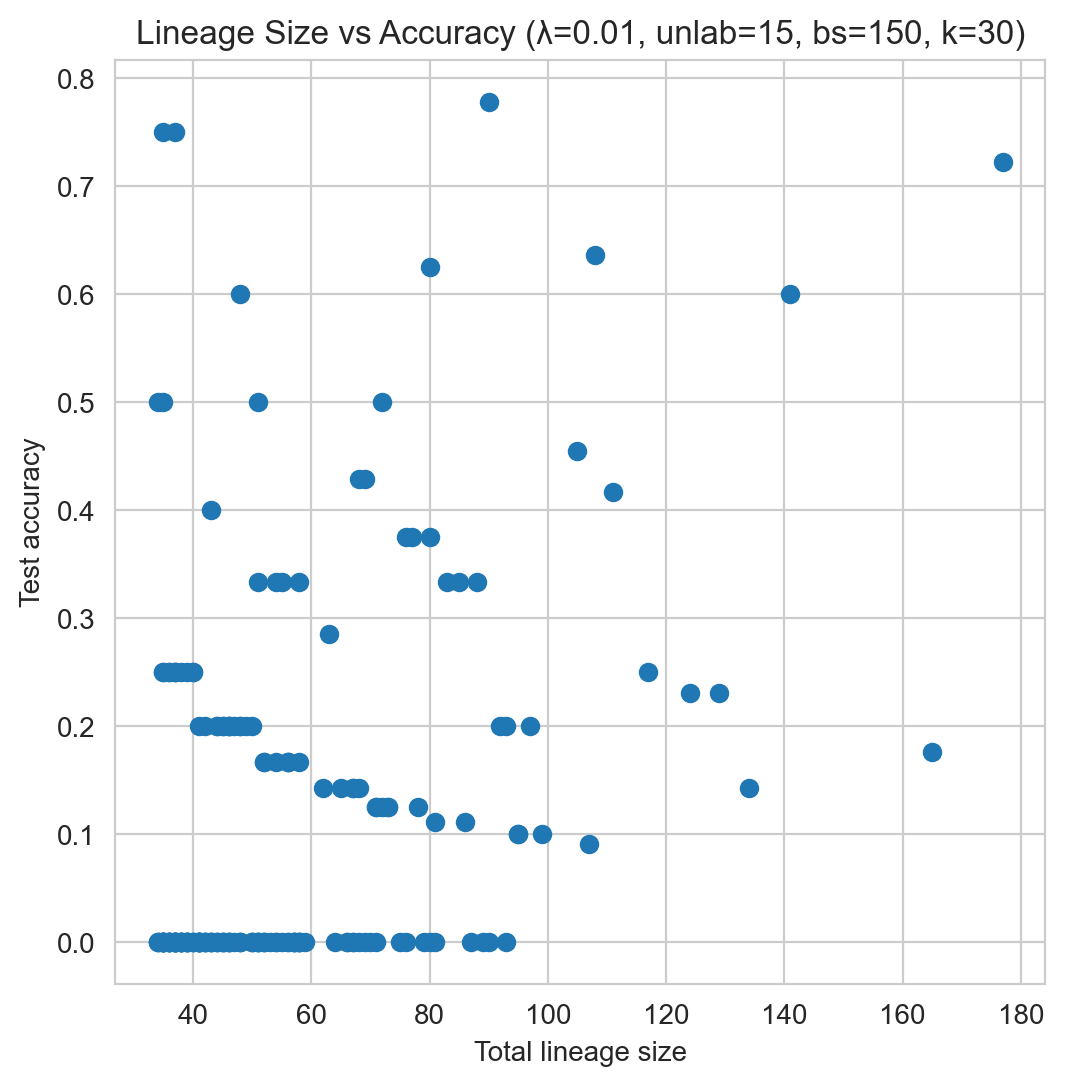

In [3]:

# -------------------------
# Initialize evaluator
# -------------------------
plotter = LCL_Eval(
    adata       = adata_all,
    clone_key   = "clone_id",
    dataset_key = "dataset",
    num_top     = 5,
    palette     = None,
    umap_kwargs = {"random_state": 42}
)

# -------------------------
# Make only the lineage-size vs accuracy plot
# -------------------------
savepath = os.path.join(
    exp_path,
    f"lineageSize_vs_acc_λ0.01_unlab15_bs150_k{k}.png"
)

plotter.plot_lineage_size_vs_accuracy(
    train_embeddings = train_emb,
    train_labels     = train_labels,
    test_embeddings  = test_emb,
    test_labels      = test_labels,
    k                = k,
    figsize          = (6, 6),
    title            = "Lineage Size vs Accuracy (λ=0.01, unlab=15, bs=150, k=30)",
    savepath         = savepath
)

print(f"Saved plot to:\n{savepath}")

In [4]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import pearsonr, spearmanr

# --------------------------------------------------
# Step 1: run the same KNN-based correctness logic
# --------------------------------------------------
gf = plotter.compute_global_freq(train_labels)
knn = KNeighborsClassifier(n_neighbors=k).fit(train_emb, train_labels)

_, _, _, corr, _ = plotter.adjusted_knn_predict_with_rank(
    knn_model    = knn,
    train_labels = train_labels,
    embeddings   = test_emb,
    labels_true  = test_labels,
    global_freq  = gf,
    k            = k
)

corr = np.array(corr, dtype=int)

# --------------------------------------------------
# Step 2: define lineage size exactly as in the plot
# total size = train + test
# --------------------------------------------------
all_labels = np.concatenate([train_labels, test_labels])
unique_labs = np.unique(all_labels)
lineage_size = {lab: int(np.sum(all_labels == lab)) for lab in unique_labs}

# --------------------------------------------------
# Step 3: per-lineage test accuracy exactly as in plot
# --------------------------------------------------
per_line_acc = {}
for lab in np.unique(test_labels):
    idxs = np.where(test_labels == lab)[0]
    per_line_acc[lab] = float(np.mean(corr[idxs]))

# --------------------------------------------------
# Step 4: build arrays used in the scatter plot
# --------------------------------------------------
xs = np.array([lineage_size[lab] for lab in per_line_acc])
ys = np.array([per_line_acc[lab] for lab in per_line_acc])

# --------------------------------------------------
# Step 5: correlation
# --------------------------------------------------
pearson_corr, pearson_p = pearsonr(xs, ys)
spearman_corr, spearman_p = spearmanr(xs, ys)

print(f"Pearson correlation:  {pearson_corr:.4f} (p={pearson_p:.4g})")
print(f"Spearman correlation: {spearman_corr:.4f} (p={spearman_p:.4g})")

# --------------------------------------------------
# Optional: inspect the per-lineage table
# --------------------------------------------------
import pandas as pd

df_lineage_acc = pd.DataFrame({
    "clone_id": list(per_line_acc.keys()),
    "lineage_size_total": [lineage_size[lab] for lab in per_line_acc],
    "test_accuracy": [per_line_acc[lab] for lab in per_line_acc]
}).sort_values("lineage_size_total")

print(df_lineage_acc.head())
print(df_lineage_acc.tail())

Pearson correlation:  0.3587 (p=1.836e-07)
Spearman correlation: 0.2949 (p=2.246e-05)
    clone_id  lineage_size_total  test_accuracy
29       922                  34           0.00
63      2115                  34           0.00
31       998                  34           0.50
55      1998                  34           0.00
41      1301                  35           0.25
     clone_id  lineage_size_total  test_accuracy
176      5209                 129       0.230769
5         292                 134       0.142857
190      5714                 141       0.600000
74       2370                 165       0.176471
40       1261                 177       0.722222


In [5]:
median_size = np.median(xs)

small_mask = xs <= median_size
large_mask = xs > median_size

print("Small lineage avg acc:", ys[small_mask].mean())
print("Large lineage avg acc:", ys[large_mask].mean())

Small lineage avg acc: 0.08564356435643565
Large lineage avg acc: 0.15261329414627095
